In [8]:
%run pylib/agn_steps

# Observation of steps in gamma-ray light curves

By a "step" we mean a change, typically around a factor or two in flux, within a week.

<h5 style="text-align:right; margin-right:15px"> 2025-05-28 10:24</h5>

## Load light curve data
Note that the file `source_info_v1.pkl`, used here was copied from SLAC's s3df,
where is was last updated on May 10 2023 13:05. 
It can be found at `/sdf/home/b/burnett/work/bb_light_curves/files`.

* Loaded wtlike-generated variability info for 8669 sources from file `files/source_info_v1.pkl`

* Load uw1410 and 4FGL-DR4 info for the 8669 sources 

...

* Selected 7105 4FGL-DR4 point sources

   bll     1468
   fsrq     798
   bcu     1576
   unid    2177
   psr      314


### Detect the single-steppers
Here I select BB light curves with exactly two blocks, and record the ratio
of the two levels (the steps), and the position of the transition.
The light curves were generated with a bin width of 7 days, so the "step" position
must be at a bin boundary, the boundary position depending on the BB algorithm, its uncertainty TBD.
Ratios close to 1.0 are possibly an artifact of the BB procedure, this needs study.

Apply margin=50 weeks: <br>Found 766 candidates, with the association categories

,bcu,bll,fsrq,other,psr,unid
,188,195,34,36,42,271


In [9]:
show(f"""* Extract light curves""")    
def make_df(x):
        if x is None: return None
        return pd.DataFrame.from_dict(x)
lcs = [make_df(vdb[uw_name]['light_curve']) for uw_name in dfx.uw_name]

* Extract light curves

In [ ]:
show(f"""### Extract potential transitions: require:
    * At least 2 and less than 5 blocks 
    * at least {(end_size:=1000)} days at each end
    * No more than {(transition_size:=100)} days in the middle
    """)
lct = dict()
for name, lc in zip(dfx.index,lcs):
    if lc is None or len(lc)<2 or len(lc)>5: continue
    # start, end block sizes
    sb, eb = lc.tw[0], lc.tw.values[-1]
    if sb<end_size or eb<end_size: continue
    mb = np.sum(lc.tw.values[1:-1])
    if mb>transition_size: continue
    ce = dfx.loc[name]

    fluxes =  lc.flux.values
    a,b = fluxes[0], fluxes[-1]
    if a==0: continue
    lct[name] = (sb,mb,eb, len(lc),
                  ce['association'], ce['eflux100'], ce['e0'],   b/a, sb+0.5*mb  )
    
dft = pd.DataFrame.from_dict(lct, orient='index',
                     columns=['start_block', 'middle_block', 'end_block', 'blocks',
                               'association', 'eflux', 'epeak','flux_ratio', 'time'])

show(rf"""$\rightarrow$ Extracted subset of {len(dft)} light curves, with association categories.""")
v,n = np.unique(dft.association,  return_counts=True)
show(pd.Series(dict(list(zip(v,n))), name=''))


### Extract potential transitions: require:
* At least 2 and less than 5 blocks 
* at least 1000 days at each end
* No more than 100 days in the middle

$\rightarrow$ Extracted subset of 640 light curves, with association categoris.

,bcu,bll,fsrq,other,psr,unid
,162,147,31,32,38,230


/home/burnett/miniconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


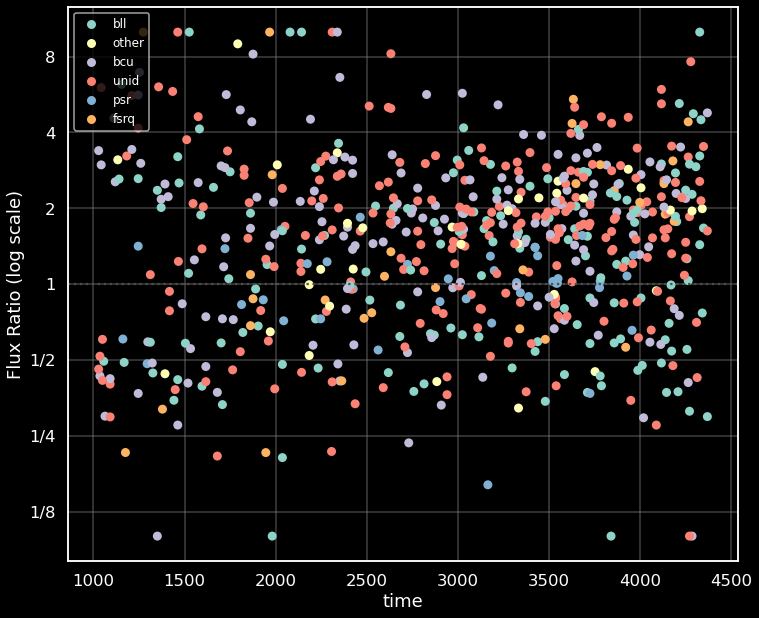

In [11]:
def ratio_display(df,  ax=None, **kwargs):
    
    eflux = df.eflux
    # sns.set_theme(font_scale=1.2)
    fig, ax = plt.subplots(figsize = (12,10)) if ax is None else (ax.figure, ax)
    r = df.flux_ratio
    
    sns.scatterplot(df, ax=ax, y=np.log10(r).clip(-1,1), 
                    x='time', hue='association', 
                    **kwargs, edgecolor='none',
                    # size=np.log10(eflux), sizes=(10, 150),
                )
    ax.set(#xlim=(-50,800), xlabel='Step time (Fermi week)', 
        
        ylabel='Flux Ratio (log scale)')
    ax.axhline(0, color="0.3", ls=':' )
    ticks = np.log10(np.array([1/8,1/4, 1/2, 1, 2, 4,8]))
    ax.set( yticks=ticks, yticklabels='1/8 1/4 1/2 1 2 4 8'.split())
    ax.legend(loc='upper left', fontsize=12,)
    return fig

ratio_display(dft);

In [14]:
show(f"""* Put them all into the cache""")
for name in dft.index:
    print(name, end='')
    WtLike(name)

* Put them all into the cache

4FGL J0001.2-0747SourceData:  4FGL J0001.2-0747: Saving to cache with key "P88Y0002_data"
	Processing 876 week files week_009.pkl - week_886.pkl , using 4 processes ...................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

Source lookup using "('4FGL J0022.0-5921',)" failed.


Exception: Source lookup using "('4FGL J0022.0-5921',)" failed.

### J0022.0-5921



<details  class="nbdoc-description" >  <summary> Analysis printout for J0022.0-5921 (03bH-0197) </summary>  <div style="margin-left: 25px;"><pre>Source name, "J0022.0-5921" <br>	Parsing J0022.0-5921<br>	is closest to uw1410 source "03bH-0197", 0.11 deg away<br>SourceData:  03bH-0197: Saving to cache with key "03bH-0197_data"<br>	Processing 876 week files week_009.pkl - week_886.pkl , using 4 processes <br><br>SourceData: Source 03bH-0197 with:<br>	 data:       101,424 photons from 2008-08-04 to 2025-05-23<br>	 exposure: 4,292,203 intervals,  average effective area 3446 cm^2 for 128.2 Ms<br>	 rates:  source 2.85e-10/s, background 2.29e-07/s, TS 48.4<br>CellData.rebin: Bin photon data into 204 30-day bins from 54683.0 to 60803.0<br>LightCurve: select 204 cells for fitting with e&gt;150.000 & n&gt;2<br>CellData.rebin: Bin photon data into 204 30-day bins from 54683.0 to 60803.0<br>LightCurve: select 204 cells for fitting with e&gt;150.000 & n&gt;2<br>Bayesian Blocks: partitioning 204  cells using LikelihoodFitness with penalty 5%<br>	found 1 / 204 blocks.<br>LightCurve: Loaded 1 / 1 cells for fitting<br>CellData.rebin: Bin photon data into 588960 15-min bins from 54683.0 to 60818.0<br></pre></div> </details>

<details  class="nbdoc-description" >  <summary> uw1410 (03bH-0197) <font color=red>(sep, r95 =6.3, 3.1 arcmin )</font> </summary>  <div style="margin-left: 25px;"><pre>jname                                  J0021.2-5917<br>fk5                               (  5.323,-59.295)<br>galactic                          (310.075,-57.413)<br>specfunc    LogParabola(3.74e-15, 1.89, 0.13, 5562)<br>e0                                         5562.163<br>eflux100                                   8.22e-13<br>ts                                           48.351<br>fitqual                                       5.760<br>locqual                                       0.690<br>aprob                                             0<br>r95                                           0.052<br>sep                                           0.106<br>Name: 03bH-0197, dtype: object<br></pre></div> </details>
<details  class="nbdoc-description" >  <summary> 4FGL-DR4 (4FGL J0022.0-5921) <font color=>(sep, r95 =0.7, 6.7 arcmin )</font> </summary>  <div style="margin-left: 25px;"><pre>fk5                    (  5.522,-59.350)<br>galactic               (309.870,-57.381)<br>specfunc        PowerLaw(1.56e-13, 2.42)<br>pivot                           1434.352<br>eflux                           3.54e-12<br>significance                      12.374<br>flags                                {2}<br>variability                       19.921<br>assoc_prob                             0<br>class1                                  <br>assoc1_name                             <br>r95                                0.112<br>sep                                0.011<br>Name: 4FGL J0022.0-5921, dtype: object<br></pre></div> </details>
<div style="margin-left: 10px"><a id="Figure_None"/><figure style="margin-left: 10px">   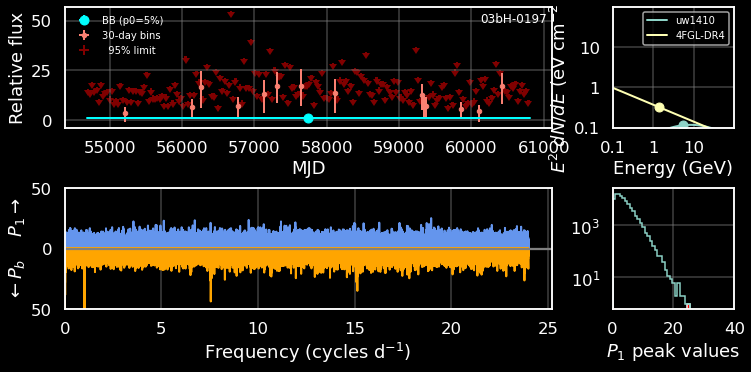 <br> </figure></div>
<details >  <summary> 1 nearby variable sources </summary>  <div style="margin-left: 25px"><table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>sep</th>
      <th>glon</th>
      <th>glat</th>
      <th>significance</th>
      <th>variability</th>
    </tr>
    <tr>
      <th>4FGL-DR4</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>4FGL J0019.2-5640</th>
      <td>2.692</td>
      <td>311.751</td>
      <td>-59.891</td>
      <td>14.666</td>
      <td>108.181</td>
    </tr>
  </tbody>
</table></div> </details>
<details >  <summary> 1 BB fits  </summary>  <div style="margin-left: 25px"><table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>t</th>
      <th>tw</th>
      <th>ts</th>
      <th>flux</th>
      <th>errors</th>
      <th>flux</th>
      <th>beta</th>
      <th>sig_beta</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>57743.000</td>
      <td>6120.000</td>
      <td>30.700</td>
      <td>1.000</td>
      <td>(-0.234, 0.255)</td>
      <td>1.002</td>
      <td>7.31e-06</td>
      <td>0.003</td>
    </tr>
  </tbody>
</table></div> </details>
<div style="margin-left: 25px;"><pre>No FFT peaks satisfying p1&gt;25 & 10&gt;f&gt;0.01</pre></div>



In [17]:
from wtlike.interface import examine_source
examine_source('J0022.0-5921')